# Customer Churn Analysis

This notebook explores customer churn patterns, validates data quality, compares the provided train/test splits, and generates visual assets for reporting.

## 1. Setup

In [17]:
from pathlib import Path
import sys

# Resolve the repository root from the notebook location so local package
# imports work consistently across machines.
PROJECT_ROOT = Path.cwd().resolve().parent
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import pandas as pd

from customer_churn_analysis.analysis import (
    build_data_quality_table,
    build_split_comparison_table,
    build_target_summary_table,
    churn_rate_by_category,
    correlation_table,
    numeric_feature_summary,
)
from customer_churn_analysis.data import prepare_and_persist_datasets
from customer_churn_analysis.visualization import (
    plot_churn_by_contract,
    plot_churn_by_subscription,
    plot_churn_rate_by_split,
    plot_correlation_heatmap,
    plot_numeric_distributions,
    set_project_theme,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')
set_project_theme()

## 2. Data Preparation

In [18]:
# Run the end-to-end preparation step: clean the raw CSV files, create
# parquet outputs, and generate reusable summary tables.
datasets = prepare_and_persist_datasets()
train_df = datasets['train']
test_df = datasets['test']
combined_df = datasets['combined']

train_df.shape, test_df.shape, combined_df.shape

((440833, 14), (64374, 14), (505207, 14))

## 3. Data Quality Review

In [19]:
# Review row counts, missing values, duplicate rows, and churn prevalence.
build_data_quality_table(datasets)

,dataset,rows,columns,duplicate_rows,total_missing_values,churn_rate
0,combined,505207,14,0,13,0.560
1,test,64374,14,0,0,0.470
2,train,440833,14,0,13,0.570


In [20]:
combined_df.head()

,customer_id,age,gender,tenure_months,usage_frequency,support_calls,payment_delay_days,subscription_type,contract_length,total_spend,last_interaction_days,churn,source_split,churn_label
0,2,30.000,Female,39.000,14.000,5.000,18.000,Standard,Annual,932.000,17.000,1,train,Churned
1,3,65.000,Female,49.000,1.000,10.000,8.000,Basic,Monthly,557.000,6.000,1,train,Churned
2,4,55.000,Female,14.000,4.000,6.000,18.000,Basic,Quarterly,185.000,3.000,1,train,Churned
3,5,58.000,Male,38.000,21.000,7.000,7.000,Standard,Monthly,396.000,29.000,1,train,Churned
4,6,23.000,Male,32.000,20.000,5.000,8.000,Basic,Monthly,617.000,20.000,1,train,Churned


## 4. Split-Level Comparison

In [21]:
# Compare headline churn prevalence between the provided train and test splits.
build_target_summary_table(combined_df)

,source_split,customers,churn_rate
0,test,64374,0.470
1,train,440832,0.570


In [22]:
# Check whether the average customer profile shifts across the two splits.
build_split_comparison_table(combined_df)

,source_split,age,tenure_months,usage_frequency,support_calls,payment_delay_days,total_spend,last_interaction_days
0,test,41.970,31.990,15.080,5.400,17.130,541.020,15.500
1,train,39.370,31.260,15.810,3.600,12.970,631.620,14.480


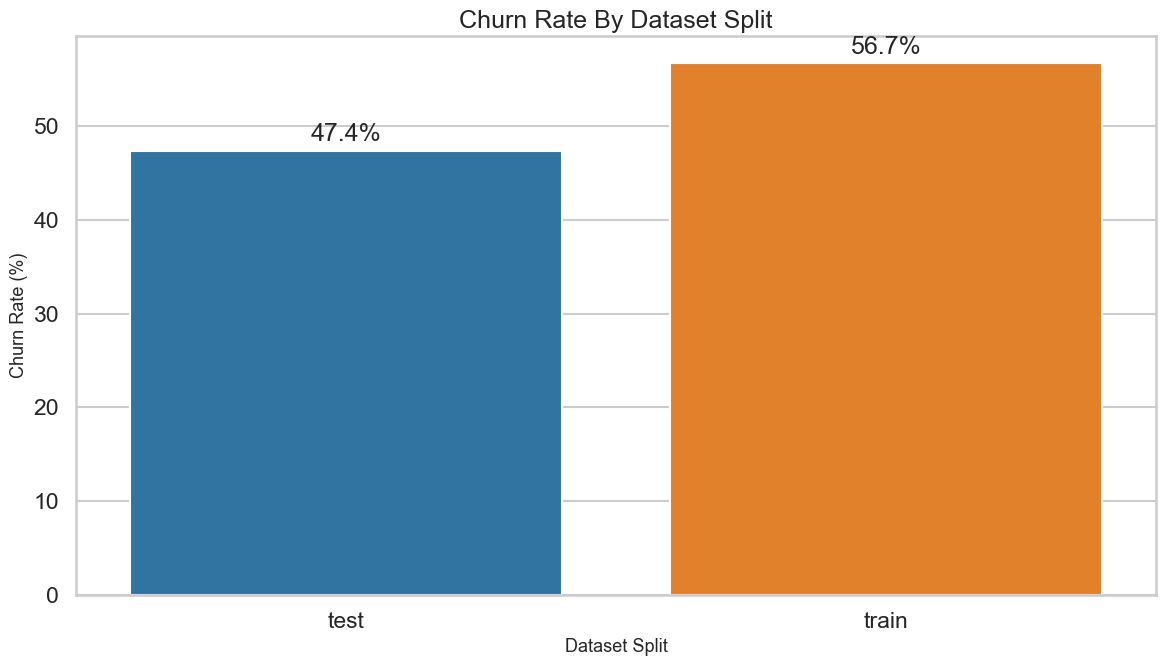

In [23]:
plot_churn_rate_by_split(combined_df)

## 5. Segment Analysis

In [24]:
# Contract structure is often commercially important, so we inspect it first.
churn_rate_by_category(combined_df, 'contract_length')

,contract_length,customers,churn_rate
1,Monthly,109234,0.900
0,Annual,198608,0.460
2,Quarterly,197364,0.460


In [25]:
churn_rate_by_category(combined_df, 'subscription_type')

,subscription_type,customers,churn_rate
0,Basic,164477,0.570
2,Standard,170630,0.550
1,Premium,170099,0.550


In [26]:
churn_rate_by_category(combined_df, 'gender')

,gender,customers,churn_rate
0,Female,224933,0.650
1,Male,280273,0.480


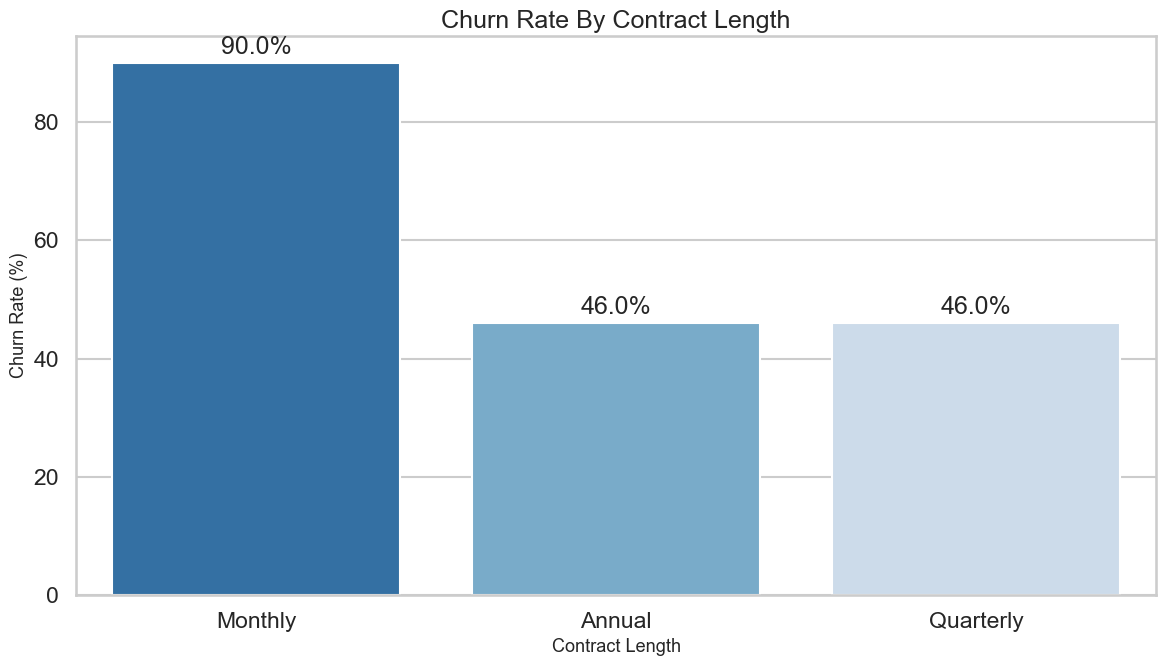

In [27]:
plot_churn_by_contract(combined_df)

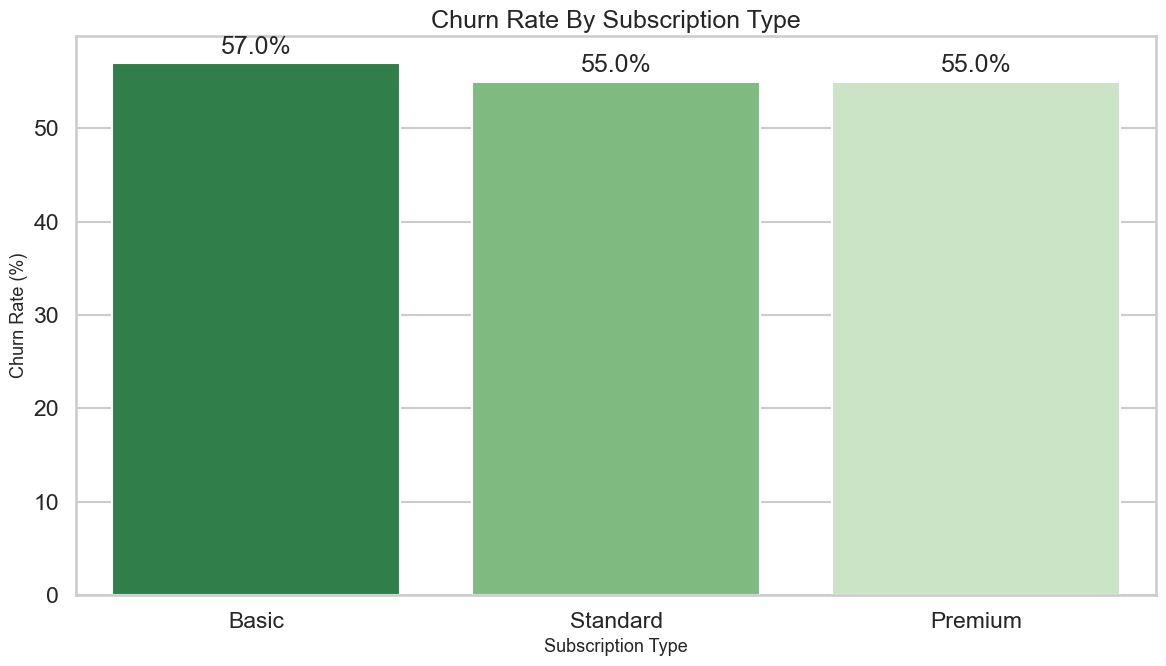

In [28]:
plot_churn_by_subscription(combined_df)

## 6. Numeric Drivers

In [29]:
# Compare the mean behavioural and commercial metrics for churned vs retained customers.
numeric_feature_summary(combined_df)

churn_label,feature,Churned,Retained
0,age,41.870,37.000
1,tenure_months,31.020,31.760
2,usage_frequency,15.300,16.230
3,support_calls,5.280,2.030
4,payment_delay_days,15.990,10.380
5,total_spend,538.900,721.390
6,last_interaction_days,15.590,13.390


In [30]:
# Rank numeric variables by how strongly they move with churn.
correlation_table(combined_df)

support_calls            0.516
total_spend             -0.370
payment_delay_days       0.330
age                      0.191
last_interaction_days    0.127
usage_frequency         -0.053
tenure_months           -0.021
Name: churn, dtype: float64

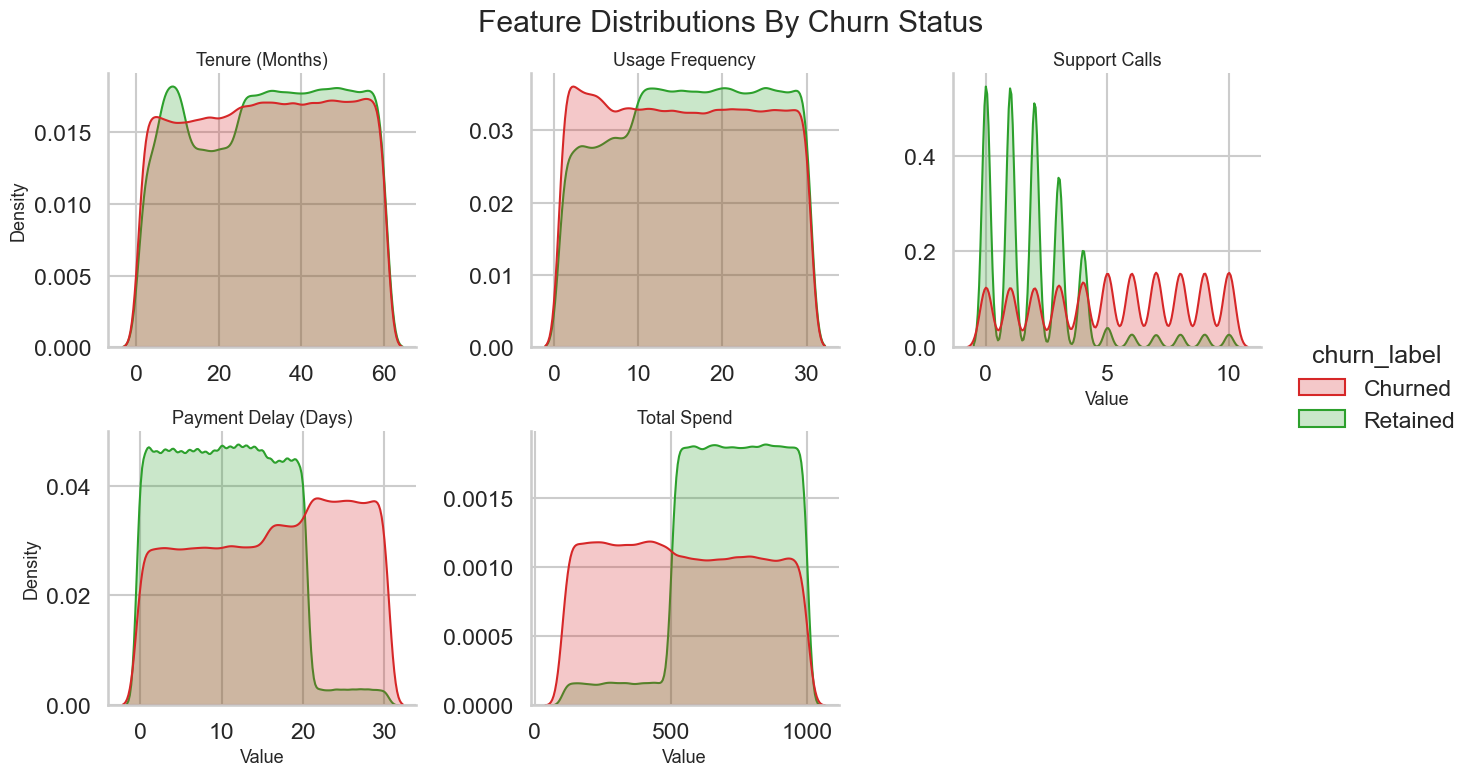

In [31]:
plot_numeric_distributions(combined_df)

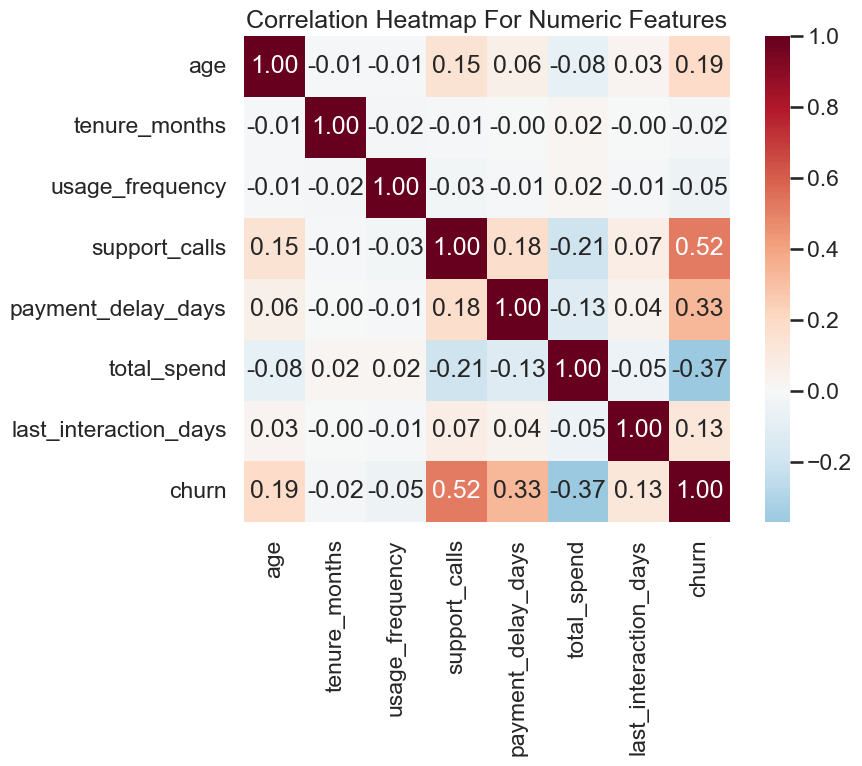

In [32]:
plot_correlation_heatmap(combined_df)

## 7. Interpretation

Use the visualisations and summary tables in `outputs/` alongside `reports/executive_summary.md` to communicate the main retention insights. A strong next step would be to extend this project with feature engineering and churn prediction modelling once the exploratory findings are validated.